This notebook serves as a demo to test creatively generated mixtures of 2 and 6 images, based on the creativity metric proposed by [Quantitative Measures of Task-Oriented Creativity in Popular Generative Vision Models](https://arxiv.org/pdf/2505.04497). I generated this primarily using Claude Code with some additional tweaks to parameters etc.

In [14]:
from typing import Union

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

from sklearn.neighbors import NearestNeighbors

# ─────────────────────────────────────────────────────────────
# 1. Data
# ─────────────────────────────────────────────────────────────

def get_mnist_26(batch_size: int = 128, train: bool = True):
    """Return a DataLoader containing only MNIST digits 2 and 6."""
    dataset = torchvision.datasets.MNIST(
        root="./data", train=train, download=True,
        transform=transforms.ToTensor()
    )
    indices = [i for i, y in enumerate(dataset.targets.tolist()) if y in (2, 6)]
    loader = DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=train)
    return loader


def cache_flat_images(loader) -> np.ndarray:
    """Flatten all images in a loader into an (N, 784) numpy array."""
    parts = []
    for x, _ in loader:
        parts.append(x.view(x.size(0), -1).numpy())
    return np.concatenate(parts, axis=0)

In [15]:
# ─────────────────────────────────────────────────────────────
# 2. VAE
# ─────────────────────────────────────────────────────────────

class VAE(nn.Module):
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_body = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def sample(self, n: int, device) -> torch.Tensor:
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)


def vae_loss(x_recon, x, mu, logvar, beta: float = 1.0):
    recon = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl

In [16]:
# ─────────────────────────────────────────────────────────────
# 3. Classifier  (2 → class 0,  6 → class 1)
# ─────────────────────────────────────────────────────────────

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.net(x)

    def probs(self, x):
        return F.softmax(self.forward(x), dim=1)

In [17]:
# ─────────────────────────────────────────────────────────────
# 4. Training helpers
# ─────────────────────────────────────────────────────────────

def train_vae(vae, loader, epochs: int = 20, lr: float = 1e-3,
              device: Union[str, torch.device] = "cpu", beta: float = 1.0):
    opt = optim.Adam(vae.parameters(), lr=lr)
    vae.train()
    for epoch in range(epochs):
        total = 0.0
        for x, _ in loader:
            x = x.to(device)
            x_recon, mu, logvar = vae(x)
            loss = vae_loss(x_recon, x, mu, logvar, beta=beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  [VAE] epoch {epoch+1:>3}/{epochs}  loss={total/len(loader):.4f}")


def train_classifier(clf, loader, epochs: int = 10, lr: float = 1e-3, device: Union[str, torch.device] = "cpu"):
    opt = optim.Adam(clf.parameters(), lr=lr)
    clf.train()
    for epoch in range(epochs):
        total, correct, n = 0.0, 0, 0
        for x, y in loader:
            x = x.to(device)
            y = (y == 6).long().to(device)   # 2→0, 6→1
            logits = clf(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total   += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            n       += y.size(0)
        if (epoch + 1) % 5 == 0:
            print(f"  [CLF] epoch {epoch+1:>3}/{epochs}  "
                  f"loss={total/len(loader):.4f}  acc={correct/n:.4f}")


This next code snippet is the implementation of the creativity metrics used in the paper. Essentially, they use a formula for creativity as a combination of a novelty and usefulness score. The usefulness just tracks the success at generating an image that the classifier labels as equally likely to be a 2 and a 6 (i.e. the min of both probabilities). The novelty score tries to detect the distance from the training set to the generated image using a nearest neighbors classifier. It only uses one neighbor because it wants to track closeness to any training example. As `nn_dist` gets farther from the training examples, this term approaches 1. This metric then evenly weights both usefulness and novelty for an overall creativity score

In [18]:
# ─────────────────────────────────────────────────────────────
# 5. Creativity scoring  (Ramaswamy et al.)
# ─────────────────────────────────────────────────────────────

def score_creativity(images: torch.Tensor, clf: Classifier,
                     train_flat: np.ndarray, device: Union[str, torch.device] = "cpu",
                     alpha: float = 0.5):
    """
    Compute per-image creativity scores.

    Creativity(x) = Novelty(x)^alpha * Usefulness(x)^(1-alpha)

    Usefulness  = min(P(2|x), P(6|x))
                  Peaks when the classifier is equally confident the image
                  is a 2 AND a 6 — the ideal creative combination.

    Novelty     = nn_dist / (1 + nn_dist)
                  Saturates toward 1 as the image moves away from all
                  training examples; 0 if the image is a copy of one.
    """
    clf.eval()
    with torch.no_grad():
        probs = clf.probs(images.to(device)).cpu().numpy()   # (N, 2)

    usefulness = np.minimum(probs[:, 0], probs[:, 1])        # (N,)

    flat = images.view(images.size(0), -1).cpu().numpy()     # (N, 784)
    nbrs = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(train_flat)
    nn_dist = nbrs.kneighbors(flat)[0][:, 0]                 # (N,)
    novelty = nn_dist / (1.0 + nn_dist)

    creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
    return creativity, novelty, usefulness

## Extended Creativity Metric

The simple metric above conflates two separate ideas under "novelty" (pixel distance) and collapses task-relevance into a single min-probability term. The extended metric decomposes creativity into three orthogonal factors:

| Term | What it measures | Implementation |
|---|---|---|
| **Structural novelty** | Topological difference from any training image | Wasserstein-1 distance between the sample's H1 persistence diagram (sublevel-set filtration on pixel values) and the nearest diagram in a training subset, normalised as $d/(1+d)$ |
| **Realness / interpretability** | Does the image look like a plausible handwritten mark? | $1 / (1 + \text{MSE}(x, \hat{x}))$ where $\hat{x}$ is reconstructed by an autoencoder trained on **all 10** MNIST classes |
| **Class ambiguity** | Is the classifier maximally uncertain between 2 and 6? | Jensen-Shannon divergence between the classifier's output $p$ and the uniform distribution $u = [0.5, 0.5]$, using log base 2 so JS $\in [0, 1]$; maximised when $p = u$ |

Combined as a weighted geometric mean:

$$\text{ExtCreativity}(x) = \text{StructuralNovelty}(x)^{w_1} \cdot \text{Realness}(x)^{w_2} \cdot \text{Ambiguity}(x)^{w_3}$$

The realness and ambiguity terms are differentiable through the AE and classifier, so two of the three objectives can be directly optimised by gradient ascent. Topological novelty is evaluated post-hoc only.

In [19]:
# ─────────────────────────────────────────────────────────────
# 5b. Extended creativity components
# ─────────────────────────────────────────────────────────────

# ── 5b-i. General autoencoder (trained on all MNIST) ─────────

class GeneralAE(nn.Module):
    """Simple AE trained on all 10 MNIST classes.  Low reconstruction
    error means the image looks like a plausible handwritten mark."""
    def __init__(self, latent_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_general_ae(ae: GeneralAE, epochs: int = 10, lr: float = 1e-3,
                     device: Union[str, torch.device] = "cpu"):
    """Train the general AE on all 10 MNIST classes."""
    full_dataset = torchvision.datasets.MNIST(
        root="./data", train=True, download=True,
        transform=transforms.ToTensor()
    )
    loader = DataLoader(full_dataset, batch_size=256, shuffle=True)
    opt = optim.Adam(ae.parameters(), lr=lr)
    ae.train()
    for epoch in range(epochs):
        total = 0.0
        for x, _ in loader:
            x = x.to(device)
            loss = F.mse_loss(ae(x), x)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  [AE] epoch {epoch+1:>3}/{epochs}  loss={total/len(loader):.6f}")


# ── 5b-ii. Persistent homology ────────────────────────────────
# Uses gudhi (cubical complex, H1) + persim (Wasserstein distance).

try:
    import gudhi
    from persim import wasserstein as _wasserstein
    TOPO_AVAILABLE = True
except ImportError:
    TOPO_AVAILABLE = False
    print("gudhi / persim not found — structural novelty will be set to 0.")
    print("Install with:  pip install gudhi persim")


def _persistence_h1(img_np: np.ndarray) -> np.ndarray:
    """H1 persistence diagram via cubical sublevel-set filtration.
    Infinite deaths are dropped; returns [[0,0]] if no finite H1 features."""
    cc = gudhi.CubicalComplex(
        dimensions=[28, 28],
        top_dimensional_cells=img_np.flatten().tolist()
    )
    cc.compute_persistence()
    dgm = cc.persistence_intervals_in_dimension(1)
    if len(dgm) == 0:
        return np.array([[0.0, 0.0]])
    finite = dgm[np.isfinite(dgm[:, 1])]
    return finite if len(finite) > 0 else np.array([[0.0, 0.0]])


def compute_train_diagrams(train_flat: np.ndarray,
                            n_samples: int = 150,
                            seed: int = 0) -> list:
    """Compute H1 diagrams for a random subset of training images."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(train_flat), size=min(n_samples, len(train_flat)),
                     replace=False)
    diagrams = []
    for i, j in enumerate(idx):
        diagrams.append(_persistence_h1(train_flat[j].reshape(28, 28)))
        if (i + 1) % 50 == 0:
            print(f"  [TOPO] {i+1}/{len(idx)} training diagrams computed")
    return diagrams

def _wd(d1, d2) -> float:
    r = _wasserstein(d1, d2, matching=False)
    return float(r[0]) if isinstance(r, tuple) else float(r)

def topological_novelty(images: torch.Tensor, train_diagrams: list) -> np.ndarray:
    """Min Wasserstein-1 distance to any training H1 diagram, normalised
    as d / (1 + d).  Requires TOPO_AVAILABLE."""
    imgs_np = images.squeeze().numpy()   # (N, 28, 28)
    scores = []
    for img in imgs_np:
        dgm = _persistence_h1(img)
        min_d = min(_wd(dgm, td) for td in train_diagrams)
        scores.append(min_d / (1.0 + min_d))
    return np.array(scores, dtype=np.float32)


# ── 5b-iii. Jensen-Shannon ambiguity ─────────────────────────


def js_ambiguity(probs: np.ndarray) -> np.ndarray:
    """
    JS divergence (log base 2) between each row of `probs` and the
    uniform distribution u = [0.5, 0.5].  Result is in [0, 1];
    equals 1 when p = [0.5, 0.5] (maximum uncertainty).
    """
    u = np.full_like(probs, 0.5)
    m = 0.5 * (probs + u)
    eps = 1e-10
    kl_pm = np.sum(probs * np.log2((probs + eps) / (m + eps)), axis=1)
    kl_um = np.sum(u     * np.log2((u     + eps) / (m + eps)), axis=1)
    return np.clip(0.5 * kl_pm + 0.5 * kl_um, 0.0, 1.0)


def js_ambiguity_torch(probs: torch.Tensor) -> torch.Tensor:
    """Differentiable version of js_ambiguity for gradient-based optimisation."""
    u = torch.full_like(probs, 0.5)
    m = 0.5 * (probs + u)
    eps = 1e-10
    kl_pm = (probs * torch.log2((probs + eps) / (m + eps))).sum(dim=1)
    kl_um = (u     * torch.log2((u     + eps) / (m + eps))).sum(dim=1)
    return torch.clamp(0.5 * kl_pm + 0.5 * kl_um, 0.0, 1.0)


# ── 5b-iv. Extended creativity score ─────────────────────────

def score_creativity_extended(images: torch.Tensor,
                               clf: Classifier,
                               ae: GeneralAE,
                               train_flat: np.ndarray,
                               train_diagrams: list,
                               device: Union[str, torch.device] = "cpu",
                               weights: tuple = (1/3, 1/3, 1/3)):
    """
    ExtCreativity = StructuralNovelty^w1 · Realness^w2 · Ambiguity^w3

    StructuralNovelty — min Wasserstein-1 distance in H1 diagram space,
                        normalised by d/(1+d).  0 if gudhi unavailable.
    Realness          — 1 / (1 + MSE(x, AE(x))); near 1 for digit-like images.
    Ambiguity         — JS divergence from classifier output to uniform [0.5, 0.5];
                        equals 1 when the classifier is maximally uncertain.
    """
    w1, w2, w3 = weights
    ae.eval()
    clf.eval()

    with torch.no_grad():
        imgs_dev = images.to(device)
        recon    = ae(imgs_dev)
        mse      = F.mse_loss(recon, imgs_dev, reduction="none") \
                     .mean(dim=[1, 2, 3]).cpu().numpy()
        probs    = clf.probs(imgs_dev).cpu().numpy()

    realness  = 1.0 / (1.0 + mse)
    ambiguity = js_ambiguity(probs)

    if TOPO_AVAILABLE and len(train_diagrams) > 0:
        struct_novelty = topological_novelty(images.cpu(), train_diagrams)
    else:
        struct_novelty = np.zeros(len(images), dtype=np.float32)

    ext_creativity = (struct_novelty ** w1) * (realness ** w2) * (ambiguity ** w3)
    return ext_creativity, struct_novelty, realness, ambiguity

This next code snippet just generates the images. It also generates a latent space interpolation baseline as an example to compare to. To generate the new images, it does a search over the latent space with the goal of maximizing the creativity metric

In [20]:
# ─────────────────────────────────────────────────────────────
# 6a. Latent interpolation baseline
# ─────────────────────────────────────────────────────────────

def generate_interpolated(vae: VAE, loader, n_samples: int = 32,
                           t: float = 0.5, device: Union[str, torch.device] = "cpu") -> torch.Tensor:
    """
    Generate images by linearly interpolating between the encoded means
    of paired digit-2 and digit-6 examples.

        z_interp = (1 - t) * mu_2  +  t * mu_6

    t=0.5 is the midpoint — equal mixture of both identities.
    Using the posterior mean (no noise) keeps interpolations smooth and
    on the VAE manifold, but they are anchored to real training pairs,
    so novelty is inherently limited compared to free latent optimisation.
    """
    vae.eval()
    mus_2, mus_6 = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            mu, _ = vae.encode(x)
            mask_2 = (y == 2)
            mask_6 = (y == 6)
            if mask_2.any():
                mus_2.append(mu[mask_2])
            if mask_6.any():
                mus_6.append(mu[mask_6])
            n2 = sum(m.size(0) for m in mus_2)
            n6 = sum(m.size(0) for m in mus_6)
            if n2 >= n_samples and n6 >= n_samples:
                break

    mus_2 = torch.cat(mus_2)[:n_samples]   # (N, latent_dim)
    mus_6 = torch.cat(mus_6)[:n_samples]   # (N, latent_dim)

    z_interp = (1.0 - t) * mus_2 + t * mus_6
    with torch.no_grad():
        return vae.decoder(z_interp).cpu()


# ─────────────────────────────────────────────────────────────
# 6b. Creative generation  (latent optimisation)
# ─────────────────────────────────────────────────────────────

def generate_creative(vae: VAE, clf: Classifier, train_flat: np.ndarray,
                      n_samples: int = 32, n_steps: int = 300,
                      lr: float = 0.05, device: Union[str, torch.device] = "cpu",
                      alpha: float = 0.5) -> torch.Tensor:
    """
    Search for latent codes z* that maximise the creativity objective.

    Unlike latent interpolation (which mixes known encodings), this
    directly optimises in the full latent space, allowing the decoder
    to reach configurations never seen during training — satisfying the
    'novelty' requirement — while the classifier loss drives the images
    toward ambiguous 2/6 territory — satisfying 'usefulness'.

    The gradient flows through the VAE decoder and the classifier,
    so both objectives shape the latent code simultaneously.
    """
    vae.eval()
    clf.eval()

    # Initialise latent codes as learnable parameters
    z = torch.randn(n_samples, vae.latent_dim, device=device, requires_grad=True)
    opt = optim.Adam([z], lr=lr)

    # Pre-load training set on device for differentiable nearest-neighbour approx
    train_t = torch.tensor(train_flat, dtype=torch.float32, device=device)

    for step in range(n_steps):
        opt.zero_grad()

        images = vae.decoder(z)                               # (N, 1, 28, 28)
        probs  = clf.probs(images)                            # (N, 2)

        # Usefulness: both class probabilities should be high simultaneously
        usefulness = torch.min(probs[:, 0], probs[:, 1])     # (N,)

        # Novelty: differentiable soft minimum distance to training set
        flat   = images.view(n_samples, -1)                   # (N, 784)
        dists  = torch.cdist(flat, train_t)                   # (N, M)
        nn_d   = dists.min(dim=1).values                      # (N,)
        novelty = nn_d / (1.0 + nn_d)

        # Creativity objective (negate for minimisation)
        creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
        loss = -creativity.mean()

        loss.backward()
        opt.step()

        if (step + 1) % 75 == 0:
            print(f"  [OPT] step {step+1:>4}/{n_steps}  "
                  f"creativity={creativity.mean().item():.4f}  "
                  f"novelty={novelty.mean().item():.4f}  "
                  f"usefulness={usefulness.mean().item():.4f}")

    with torch.no_grad():
        return vae.decoder(z).cpu()

In [21]:
# ─────────────────────────────────────────────────────────────
# 6c. Creative generation — extended objective
# ─────────────────────────────────────────────────────────────

def generate_creative_extended(vae: VAE, clf: Classifier, ae: GeneralAE,
                                train_flat: np.ndarray,
                                n_samples: int = 32, n_steps: int = 300,
                                lr: float = 0.05,
                                device: Union[str, torch.device] = "cpu",
                                weights: tuple = (1/4, 1/4, 1/2)) -> torch.Tensor:
    """
    Optimise latent codes to maximise the differentiable subset of the
    extended creativity objective:

        Loss = − (PixelNovelty^w1 · Realness^w2 · JSAmbiguity^w3)

    All three terms are differentiable, so gradients flow through the VAE
    decoder, the general AE, and the classifier simultaneously.

    Topological (Wasserstein) novelty cannot be backpropagated through, so
    it is only used for post-hoc evaluation in score_creativity_extended.
    PixelNovelty (nearest-neighbour distance in pixel space) is used as a
    differentiable proxy for structural novelty during optimisation.
    """
    vae.eval()
    clf.eval()
    ae.eval()

    w1, w2, w3 = weights

    z = torch.randn(n_samples, vae.latent_dim, device=device, requires_grad=True)
    opt = optim.Adam([z], lr=lr)
    train_t = torch.tensor(train_flat, dtype=torch.float32, device=device)

    for step in range(n_steps):
        opt.zero_grad()

        images = vae.decoder(z)                               # (N, 1, 28, 28)
        flat   = images.view(n_samples, -1)                   # (N, 784)

        # Pixel novelty (proxy for structural novelty)
        dists       = torch.cdist(flat, train_t)              # (N, M)
        nn_d        = dists.min(dim=1).values                 # (N,)
        pixel_nov   = nn_d / (1.0 + nn_d)

        # Realness: low AE reconstruction error → high score
        mse      = F.mse_loss(ae(images), images, reduction="none") \
                     .mean(dim=[1, 2, 3])
        realness = 1.0 / (1.0 + mse)

        # Class ambiguity: JS divergence toward uniform [0.5, 0.5]
        ambiguity = js_ambiguity_torch(clf.probs(images))

        ext_creativity = (pixel_nov ** w1) * (realness ** w2) * (ambiguity ** w3)
        (-ext_creativity.mean()).backward()
        opt.step()

        if (step + 1) % 75 == 0:
            print(f"  [EXT] step {step+1:>4}/{n_steps}  "
                  f"ext={ext_creativity.mean().item():.4f}  "
                  f"nov={pixel_nov.mean().item():.4f}  "
                  f"real={realness.mean().item():.4f}  "
                  f"amb={ambiguity.mean().item():.4f}")

    with torch.no_grad():
        return vae.decoder(z).cpu()

In [22]:
# ─────────────────────────────────────────────────────────────
# 7. Visualisation
# ─────────────────────────────────────────────────────────────

def visualize(images: torch.Tensor, creativity, novelty, usefulness,
              title: str, filename: str, n: int = 16):
    n = min(n, len(images))
    order = np.argsort(creativity)[::-1][:n]   # top-n by creativity

    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 2.2))
    axes = np.array(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for i, idx in enumerate(order):
        axes[i].imshow(images[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[i].set_title(
            f"C={creativity[idx]:.2f}\nN={novelty[idx]:.2f} U={usefulness[idx]:.2f}",
            fontsize=6.5
        )
        axes[i].axis("off")

    plt.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {filename}")

In [23]:
# ─────────────────────────────────────────────────────────────
# 8. Comparison utilities
# ─────────────────────────────────────────────────────────────

def get_probs(images: torch.Tensor, clf: Classifier, device: Union[str, torch.device] = "cpu") -> np.ndarray:
    """Return softmax probabilities [P(2|x), P(6|x)] for each image. Shape (N, 2)."""
    clf.eval()
    with torch.no_grad():
        return clf.probs(images.to(device)).cpu().numpy()


def plot_comparison(probs_dict: dict, creativity_dict: dict,
                    filename: str = "comparison.png"):
    """
    Two-panel figure:
      Left  — box plots of P(2|x) and P(6|x) for each method.
               Ideal creative combination → both boxes centred near 0.5.
      Right — box plots of creativity, novelty, and usefulness per method.
    """
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    methods = list(probs_dict.keys())

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: classifier probabilities ────────────────────────
    n_methods = len(methods)
    width = 0.35
    x = np.arange(n_methods)

    for k, (label, col) in enumerate([("P(2|x)", "#4C72B0"), ("P(6|x)", "#DD8452")]):
        col_idx = 0 if label == "P(2|x)" else 1
        data = [probs_dict[m][:, col_idx] for m in methods]
        ax1.boxplot(data, positions=x + (k - 0.5) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col),
                    capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3,
                                    markersize=3))

    ax1.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_ylabel("Classifier probability")
    ax1.set_title("Classifier output per method\n(both near 0.5 = good 2+6 mixture)")
    handles = [Patch(facecolor="#4C72B0", alpha=0.7, label="P(2|x)"),
               Patch(facecolor="#DD8452", alpha=0.7, label="P(6|x)"),
               Line2D([0], [0], color="black", linestyle="--", label="ideal (0.5)")]
    ax1.legend(handles=handles, fontsize=8)

    # ── Right: creativity metrics ──────────────────────────────
    metric_labels  = ["Creativity", "Novelty", "Usefulness"]
    metric_colours = ["#55A868", "#C44E52", "#8172B2"]
    x2 = np.arange(n_methods)

    for k, (_, mcol) in enumerate(zip(metric_labels, metric_colours)):
        data = [creativity_dict[m][k] for m in methods]
        ax2.boxplot(data, positions=x2 + (k - 1) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=mcol, alpha=0.7),
                    whiskerprops=dict(color=mcol),
                    capprops=dict(color=mcol),
                    flierprops=dict(marker="o", color=mcol, alpha=0.3,
                                    markersize=3))

    ax2.set_xticks(x2)
    ax2.set_xticklabels(methods)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("Score")
    ax2.set_title("Creativity metrics per method")
    handles2 = [Patch(facecolor=c, alpha=0.7, label=l)
                for l, c in zip(metric_labels, metric_colours)]
    ax2.legend(handles=handles2, fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {filename}")

In [24]:
def plot_comparison_extended(probs_dict: dict,
                              simple_dict: dict,
                              extended_dict: dict,
                              filename: str = "comparison_extended.png"):
    """
    Three-panel figure comparing all methods on:
      Left   — classifier probabilities P(2|x) and P(6|x)
      Middle — simple creativity scores (Creativity, Novelty, Usefulness)
      Right  — extended creativity scores (ExtCreativity, StructNovelty,
                                           Realness, Ambiguity)
    """
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    methods = list(probs_dict.keys())
    n_m = len(methods)
    width = 0.3
    x = np.arange(n_m)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # ── Panel 1: classifier probabilities ─────────────────────
    for k, (label, col) in enumerate([("P(2|x)", "#4C72B0"), ("P(6|x)", "#DD8452")]):
        col_idx = 0 if k == 0 else 1
        data = [probs_dict[m][:, col_idx] for m in methods]
        ax1.boxplot(data, positions=x + (k - 0.5) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3, markersize=3))

    ax1.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, fontsize=8)
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_ylabel("Probability")
    ax1.set_title("Classifier output\n(both ≈ 0.5 = ideal mixture)")
    ax1.legend(handles=[
        Patch(facecolor="#4C72B0", alpha=0.7, label="P(2|x)"),
        Patch(facecolor="#DD8452", alpha=0.7, label="P(6|x)"),
        Line2D([0], [0], color="black", linestyle="--", label="ideal (0.5)")
    ], fontsize=7)

    # ── Panel 2: simple creativity ─────────────────────────────
    s_labels  = ["Creativity", "Novelty", "Usefulness"]
    s_colours = ["#55A868",   "#C44E52",  "#8172B2"]
    for k, (_, col) in enumerate(zip(s_labels, s_colours)):
        data = [simple_dict[m][k] for m in methods]
        ax2.boxplot(data, positions=x + (k - 1) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3, markersize=3))

    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, fontsize=8)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("Score")
    ax2.set_title("Simple creativity metric\n(Ramaswamy et al.)")
    ax2.legend(handles=[Patch(facecolor=c, alpha=0.7, label=l)
                         for l, c in zip(s_labels, s_colours)], fontsize=7)

    # ── Panel 3: extended creativity ──────────────────────────
    e_labels  = ["ExtCreativity", "StructNovelty", "Realness", "Ambiguity"]
    e_colours = ["#1f77b4",      "#ff7f0e",        "#2ca02c",  "#d62728"]
    n_e = len(e_labels)
    offsets = np.linspace(-(n_e - 1) / 2, (n_e - 1) / 2, n_e) * width

    for k, (_, col) in enumerate(zip(e_labels, e_colours)):
        data = [extended_dict[m][k] for m in methods]
        ax3.boxplot(data, positions=x + offsets[k],
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3, markersize=3))

    ax3.set_xticks(x)
    ax3.set_xticklabels(methods, fontsize=8)
    ax3.set_ylim(-0.05, 1.05)
    ax3.set_ylabel("Score")
    ax3.set_title("Extended creativity metric\n(topology + realness + ambiguity)")
    ax3.legend(handles=[Patch(facecolor=c, alpha=0.7, label=l)
                         for l, c in zip(e_labels, e_colours)], fontsize=7)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {filename}")

Device: cpu

[1] Loading MNIST digits 2 & 6 ...
    11876 training images cached.

[2] Training VAE ...
  [VAE] epoch   5/100  loss=108.3743
  [VAE] epoch  10/100  loss=86.3184
  [VAE] epoch  15/100  loss=78.4967
  [VAE] epoch  20/100  loss=74.4318
  [VAE] epoch  25/100  loss=71.6189
  [VAE] epoch  30/100  loss=69.8891
  [VAE] epoch  35/100  loss=68.4247
  [VAE] epoch  40/100  loss=67.2895
  [VAE] epoch  45/100  loss=66.4575
  [VAE] epoch  50/100  loss=65.6718
  [VAE] epoch  55/100  loss=65.0817
  [VAE] epoch  60/100  loss=64.6296
  [VAE] epoch  65/100  loss=64.0902
  [VAE] epoch  70/100  loss=63.7173
  [VAE] epoch  75/100  loss=63.4063
  [VAE] epoch  80/100  loss=63.1747
  [VAE] epoch  85/100  loss=62.7943
  [VAE] epoch  90/100  loss=62.6352
  [VAE] epoch  95/100  loss=62.3457
  [VAE] epoch 100/100  loss=62.1287

[3] Training 2-vs-6 classifier ...
  [CLF] epoch   5/10  loss=0.0009  acc=0.9999
  [CLF] epoch  10/10  loss=0.0001  acc=1.0000

[4] Training general MNIST autoencoder ...
  [

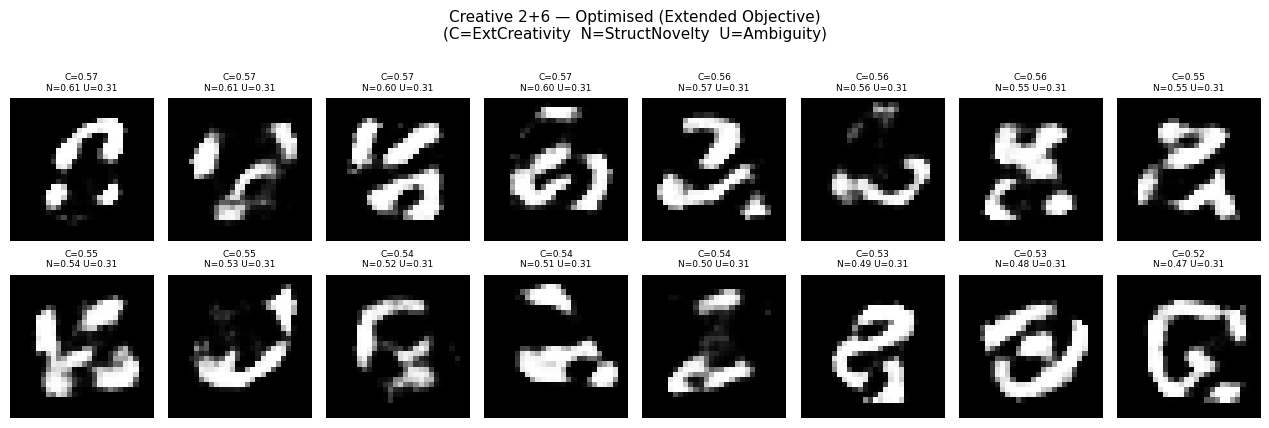

  Saved -> creative_ext_optimised.png


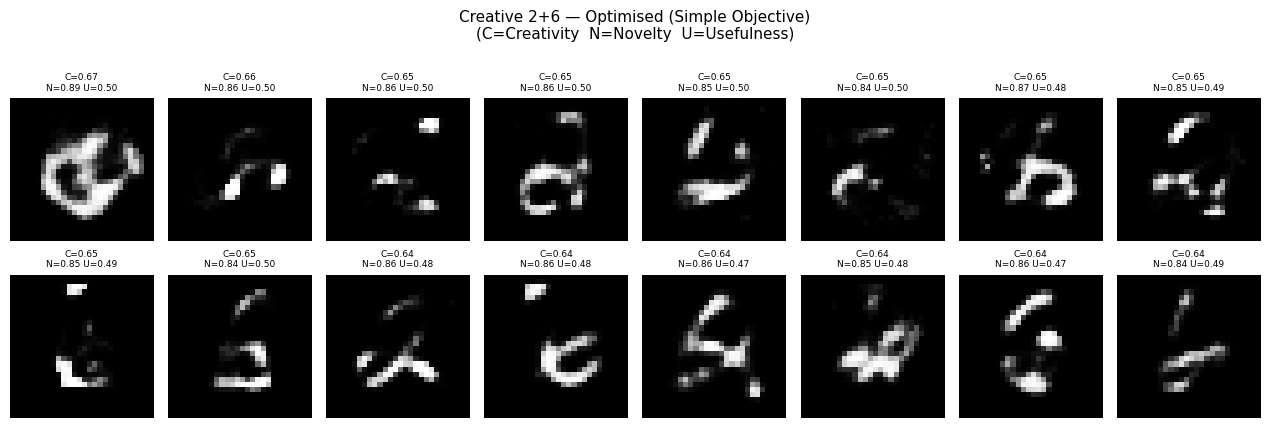

  Saved -> creative_simple_optimised.png


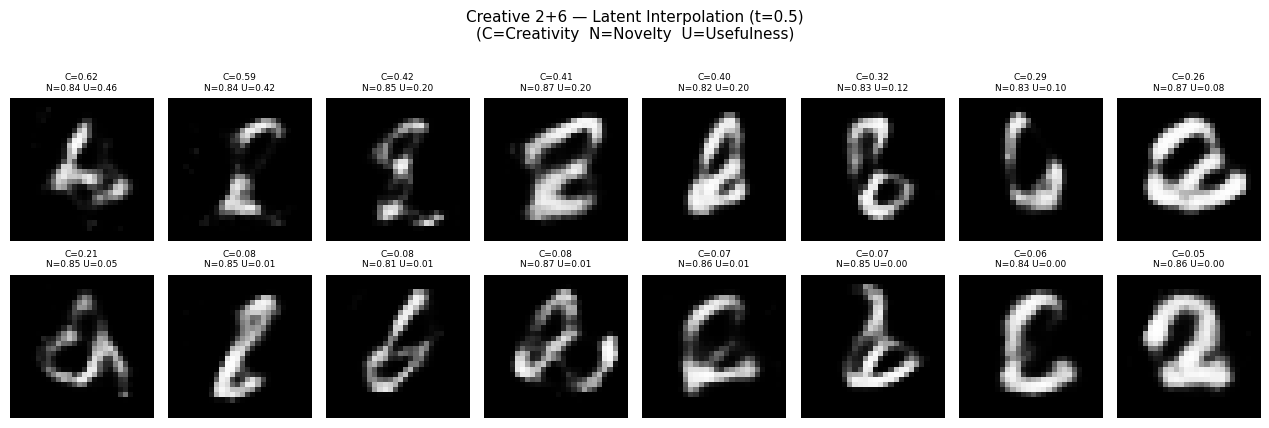

  Saved -> creative_interpolated.png


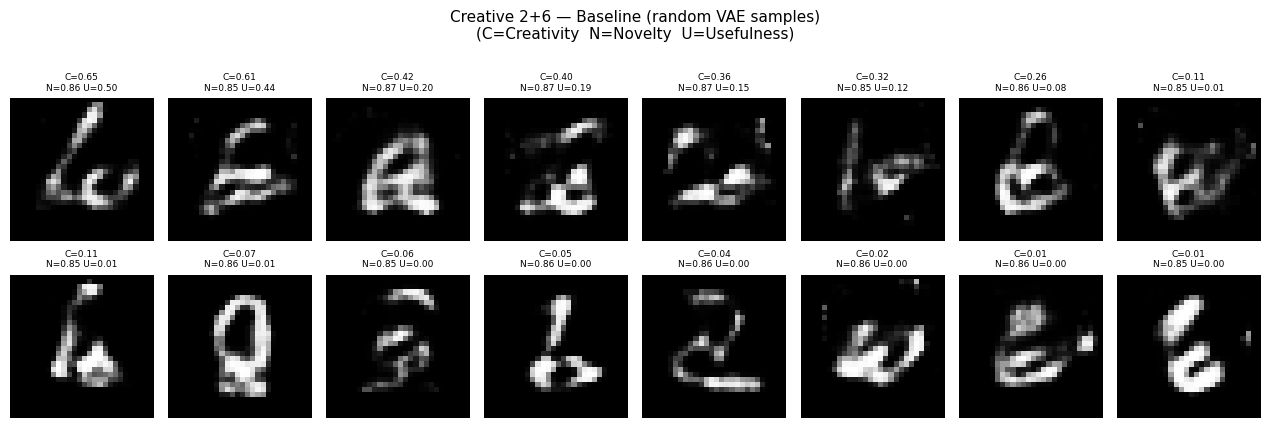

  Saved -> creative_baseline.png

[11] Saving comparison plot ...


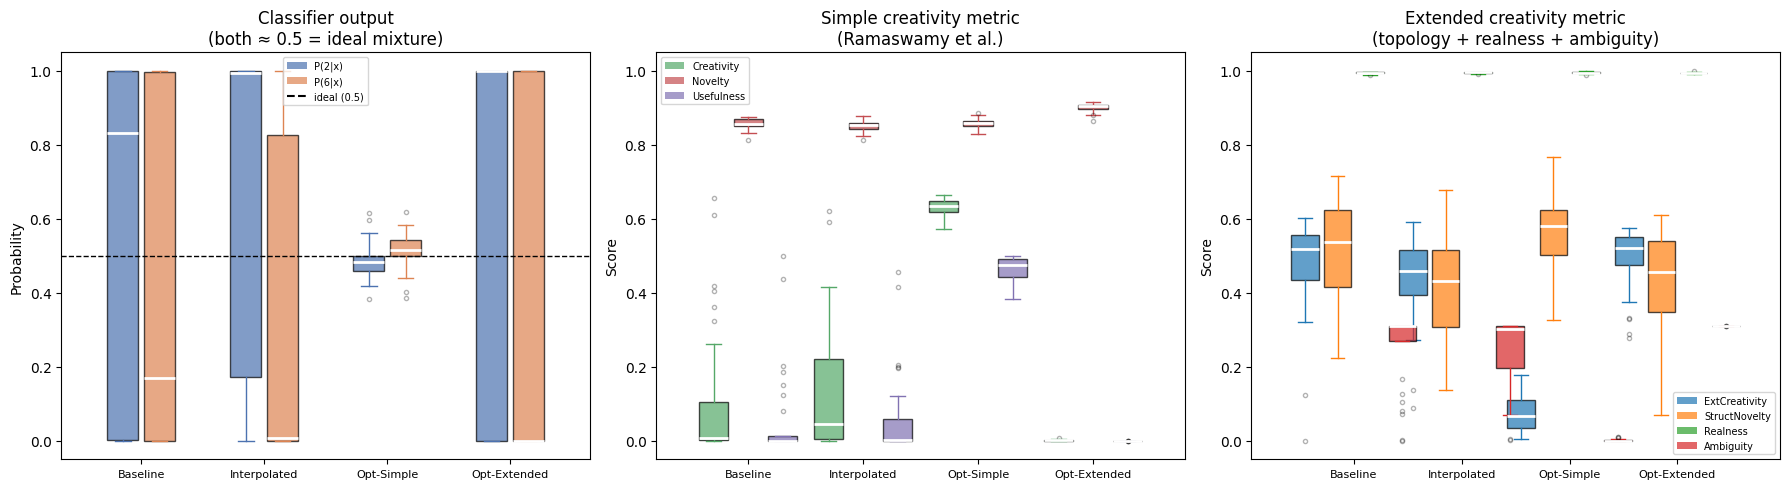

  Saved -> comparison_extended.png

Done.


In [25]:
# ─────────────────────────────────────────────────────────────
# 9. Main
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# ── Data ──────────────────────────────────────────────────
print("[1] Loading MNIST digits 2 & 6 ...")
train_loader = get_mnist_26(batch_size=128, train=True)
train_flat   = cache_flat_images(train_loader)
print(f"    {len(train_flat)} training images cached.\n")

# ── VAE ───────────────────────────────────────────────────
print("[2] Training VAE ...")
vae = VAE(latent_dim=32).to(device)
train_vae(vae, train_loader, epochs=100, lr=1e-3, device=device, beta=1.0)

# ── Classifier ────────────────────────────────────────────
print("\n[3] Training 2-vs-6 classifier ...")
clf = Classifier().to(device)
train_classifier(clf, train_loader, epochs=10, lr=1e-3, device=device)

# ── General AE (all MNIST, for realness scoring) ──────────
print("\n[4] Training general MNIST autoencoder ...")
ae = GeneralAE(latent_dim=64).to(device)
train_general_ae(ae, epochs=10, lr=1e-3, device=device)

# ── Training persistence diagrams (for topo novelty) ──────
print("\n[5] Computing training H1 persistence diagrams ...")
if TOPO_AVAILABLE:
    train_diagrams = compute_train_diagrams(train_flat, n_samples=150, seed=0)
    print(f"    {len(train_diagrams)} diagrams ready.")
else:
    train_diagrams = []
    print("    Skipped (gudhi not available).")

# ── Shared pixel-space training subset (for nn speed) ─────
rng      = np.random.default_rng(0)
sub      = rng.choice(len(train_flat), size=min(2000, len(train_flat)), replace=False)
train_sub = train_flat[sub]

# ── Generate samples ──────────────────────────────────────
print("\n[6] Generating samples ...")

with torch.no_grad():
    baseline = vae.sample(32, device).cpu()

interp = generate_interpolated(vae, train_loader, n_samples=32,
                                t=0.5, device=device)

print("  Optimising with simple creativity objective ...")
creative_simple = generate_creative(
    vae, clf, train_sub,
    n_samples=32, n_steps=300, lr=0.05, device=device, alpha=0.2
)

print("  Optimising with extended creativity objective ...")
creative_ext = generate_creative_extended(
    vae, clf, ae, train_sub,
    n_samples=32, n_steps=300, lr=0.05, device=device, weights=(1/3, 1/3, 1/3)
)

# ── Simple creativity scores ──────────────────────────────
print("\n[7] Scoring — simple metric ...")
bc, bn, bu = score_creativity(baseline,       clf, train_sub, device=device)
ic, in_, iu = score_creativity(interp,        clf, train_sub, device=device)
cc, cn, cu  = score_creativity(creative_simple, clf, train_sub, device=device)
ec, en, eu  = score_creativity(creative_ext,  clf, train_sub, device=device)

# ── Extended creativity scores ────────────────────────────
print("[8] Scoring — extended metric ...")
bec, bsn, br, ba = score_creativity_extended(
    baseline,       clf, ae, train_sub, train_diagrams, device=device)
iec, isn, ir, ia = score_creativity_extended(
    interp,         clf, ae, train_sub, train_diagrams, device=device)
cec, csn, cr, ca = score_creativity_extended(
    creative_simple, clf, ae, train_sub, train_diagrams, device=device)
eec, esn, er, ea = score_creativity_extended(
    creative_ext,   clf, ae, train_sub, train_diagrams, device=device)

# ── Summary tables ────────────────────────────────────────
print("\n[9] Summary — simple metric")
hdr = f"    {'Method':<18} {'Creativity':>10} {'Novelty':>10} {'Usefulness':>12}"
print(hdr); print(f"    {'─'*52}")
for name, c, n_, u in [("Baseline",        bc, bn, bu),
                        ("Interpolated",    ic, in_, iu),
                        ("Opt-Simple",      cc, cn, cu),
                        ("Opt-Extended",    ec, en, eu)]:
    print(f"    {name:<18} {c.mean():>10.4f} {n_.mean():>10.4f} {u.mean():>12.4f}")

print("\n[9] Summary — extended metric")
hdr2 = f"    {'Method':<18} {'ExtCreat':>10} {'StructNov':>11} {'Realness':>10} {'Ambiguity':>11}"
print(hdr2); print(f"    {'─'*64}")
for name, ec_, sn, r, a in [("Baseline",     bec, bsn, br, ba),
                              ("Interpolated", iec, isn, ir, ia),
                              ("Opt-Simple",   cec, csn, cr, ca),
                              ("Opt-Extended", eec, esn, er, ea)]:
    print(f"    {name:<18} {ec_.mean():>10.4f} {sn.mean():>11.4f} "
          f"{r.mean():>10.4f} {a.mean():>11.4f}")

# ── Classifier probability helper ────────────────────────
bp  = get_probs(baseline,        clf, device=device)
ip  = get_probs(interp,          clf, device=device)
cp  = get_probs(creative_simple, clf, device=device)
ep  = get_probs(creative_ext,    clf, device=device)

# ── Image grids ───────────────────────────────────────────
print("\n[10] Saving image grids ...")
visualize(creative_ext, eec, esn, ea,
          title="Creative 2+6 — Optimised (Extended Objective)\n"
                "(C=ExtCreativity  N=StructNovelty  U=Ambiguity)",
          filename="creative_ext_optimised.png")
visualize(creative_simple, cc, cn, cu,
          title="Creative 2+6 — Optimised (Simple Objective)\n"
                "(C=Creativity  N=Novelty  U=Usefulness)",
          filename="creative_simple_optimised.png")
visualize(interp, ic, in_, iu,
          title="Creative 2+6 — Latent Interpolation (t=0.5)\n"
                "(C=Creativity  N=Novelty  U=Usefulness)",
          filename="creative_interpolated.png")
visualize(baseline, bc, bn, bu,
          title="Creative 2+6 — Baseline (random VAE samples)\n"
                "(C=Creativity  N=Novelty  U=Usefulness)",
          filename="creative_baseline.png")

# ── Comparison plot ───────────────────────────────────────
print("\n[11] Saving comparison plot ...")
plot_comparison_extended(
    probs_dict={
        "Baseline":     bp,
        "Interpolated": ip,
        "Opt-Simple":   cp,
        "Opt-Extended": ep,
    },
    simple_dict={
        "Baseline":     (bc, bn, bu),
        "Interpolated": (ic, in_, iu),
        "Opt-Simple":   (cc, cn, cu),
        "Opt-Extended": (ec, en, eu),
    },
    extended_dict={
        "Baseline":     (bec, bsn, br, ba),
        "Interpolated": (iec, isn, ir, ia),
        "Opt-Simple":   (cec, csn, cr, ca),
        "Opt-Extended": (eec, esn, er, ea),
    },
    filename="comparison_extended.png"
)
print("\nDone.")